## Dataset Overview

This project builds a complete supervised machine learning pipeline to detect fraudulent bank transactions. Financial fraud detection is a critical real-world challenge: while the vast majority of transactions are legitimate, even a small number of undetected fraudulent transactions can cause severe financial harm to individuals and institutions.

The dataset is a synthetic simulation of bank transactions containing 6,362,620 rows. Due to the size of the full dataset, a stratified sample of 180,000 rows was used for all analysis. Stratified sampling preserved the original fraud ratio (~0.13%) so the sample accurately represents the full population.

### Importing and inspecting the dataset

In [1]:
#importing necessary libraries

import pandas as pd     
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np     

In [4]:
#loading the dataset and checking the first few rows

raw_data = pd.read_csv("/Users/sa03/Desktop/Financial_Fraud_Detection/Dataset/raw_data.csv")

raw_data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [6]:
#checking the information about the dataset

raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


We can see from above that the raw dataset has over 6million rows and 11 columns which is too big to be pushed to github hence to move forward, we will craete a "gitignore" and all thus does is it ignores the raw dataset when we hit push to github.

We would also create a sample from the dataset and use that to do all analysis and modelling because tha chuck will run faster and will also get us the results as using everything

## Starting our EDA on the Sample

In [8]:
# creating a sample dataset with 180000 rows for testing purposes and saving it as a new csv file

df = raw_data.sample(n=180000, random_state=42)
df.to_csv("/Users/sa03/Fin_Fraud_Detection/Dataset/sample_dataset.csv", index=False)
    

In [9]:
#checking the information about the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 180000 entries, 3737323 to 4003207
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            180000 non-null  int64  
 1   type            180000 non-null  object 
 2   amount          180000 non-null  float64
 3   nameOrig        180000 non-null  object 
 4   oldbalanceOrg   180000 non-null  float64
 5   newbalanceOrig  180000 non-null  float64
 6   nameDest        180000 non-null  object 
 7   oldbalanceDest  180000 non-null  float64
 8   newbalanceDest  180000 non-null  float64
 9   isFraud         180000 non-null  int64  
 10  isFlaggedFraud  180000 non-null  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 16.5+ MB


In [10]:
# checking the statistical summary of the dataset

df.describe()   

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,180000.000000,1.800000e+05,1.800000e+05,1.800000e+05,1.800000e+05,1.800000e+05,180000.000000,180000.000000
mean,243.497133,1.794040e+05,8.261726e+05,8.479770e+05,1.098739e+06,1.222772e+06,0.001306,0.000006
std,142.491059,5.689986e+05,2.873335e+06,2.909354e+06,3.352988e+06,3.606030e+06,0.036109,0.002357
min,1.000000,3.300000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,156.000000,1.343313e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
50%,239.000000,7.552461e+04,1.396805e+04,0.000000e+00,1.355848e+05,2.154960e+05,0.000000,0.000000
75%,335.000000,2.085390e+05,1.069805e+05,1.454770e+05,9.479827e+05,1.118472e+06,0.000000,0.000000
max,736.000000,3.697390e+07,3.465715e+07,3.461632e+07,2.362896e+08,2.724047e+08,1.000000,1.000000


In [11]:
#  checking the shape of the dataset

df.shape

(180000, 11)

In [12]:
#  checking for missing values

df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [13]:
df["isFraud"].value_counts()

isFraud
0    179765
1       235
Name: count, dtype: int64

After inspecting the data, we see that, our sample has 180000 rows and 11 columns, has no null values and has data types ranging from int64,float64 and a few objects in there.

## Univariate Analysis
Let us explore a few of our variables one ata time to see the relationships between them

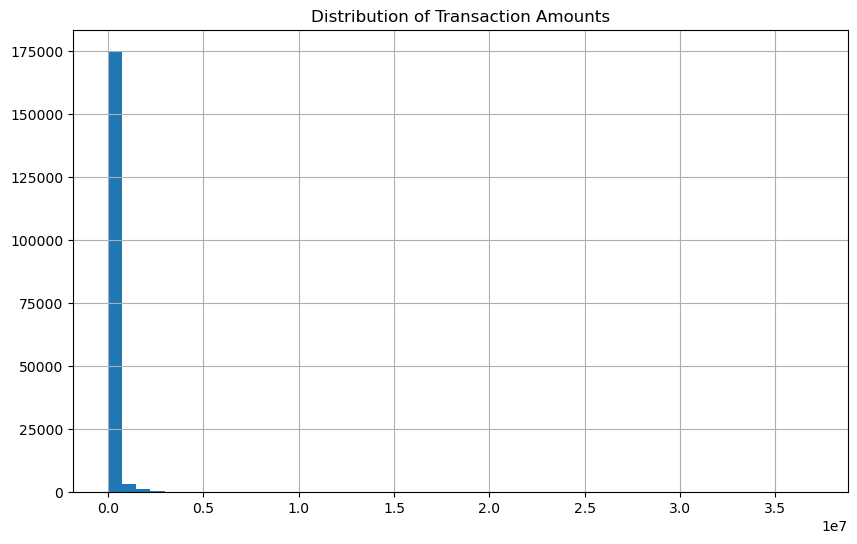

In [14]:
df["amount"].hist(bins=50, figsize=(10, 6))
plt.title("Distribution of Transaction Amounts")
plt.show()

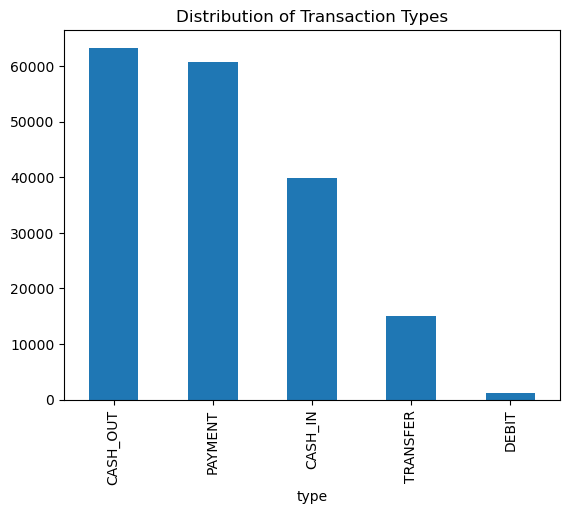

In [15]:
# transaction types
df["type"].value_counts().plot(kind="bar")
plt.title("Distribution of Transaction Types")
plt.show()

## Bivariate Analysis

Now lets explore 2 ata time

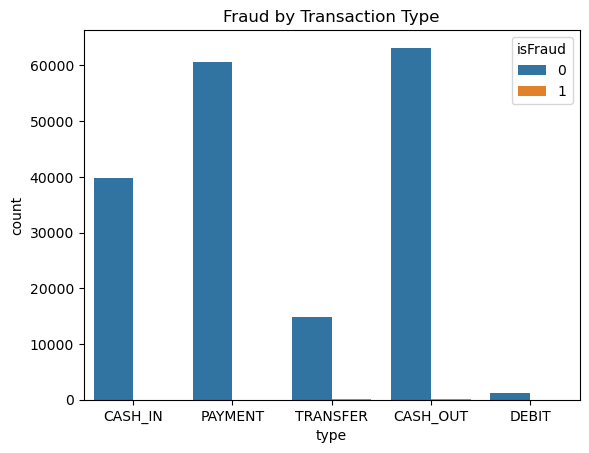

In [16]:
# Fraud by transaction type

sns.countplot(x="type", hue="isFraud", data=df)
plt.title("Fraud by Transaction Type")
plt.show()

### Fraud rate breakdown by transaction type
This section calculates the exact fraud rate for each transaction type, and then reports the percentage of fraudulent transactions for `TRANSFER` and `CASH_OUT`.

          total_transactions  fraud_transactions  fraud_rate_pct
type                                                            
TRANSFER               15023                 131          0.8720
CASH_OUT               63294                 104          0.1643


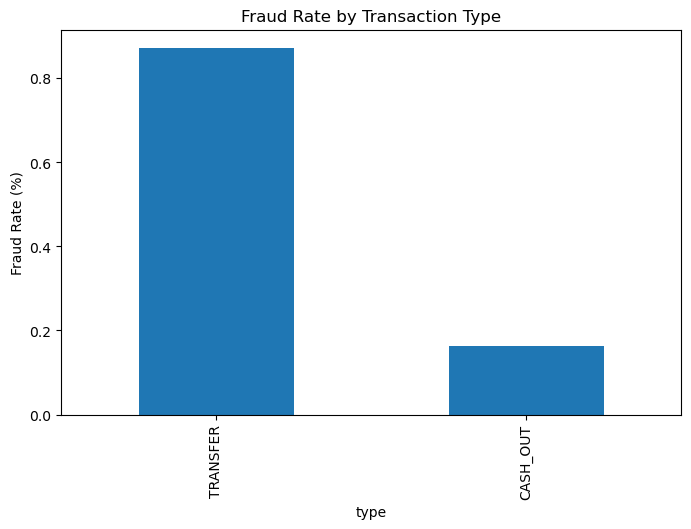

In [21]:
# Calculate fraud rate by transaction type
fraud_stats = df.groupby('type')['isFraud'].agg(total_transactions='count', fraud_transactions='sum')
fraud_stats['fraud_rate_pct'] = fraud_stats['fraud_transactions'] / fraud_stats['total_transactions'] * 100

# Display only the two relevant transaction types
fraud_rate_transfer_cashout = fraud_stats.loc[['TRANSFER', 'CASH_OUT']]
print(fraud_rate_transfer_cashout[['total_transactions', 'fraud_transactions', 'fraud_rate_pct']].round(4))

# Optional bar plot for visual comparison
fraud_rate_transfer_cashout['fraud_rate_pct'].plot(kind='bar', figsize=(8, 5))
plt.ylabel('Fraud Rate (%)')
plt.title('Fraud Rate by Transaction Type')
plt.show()

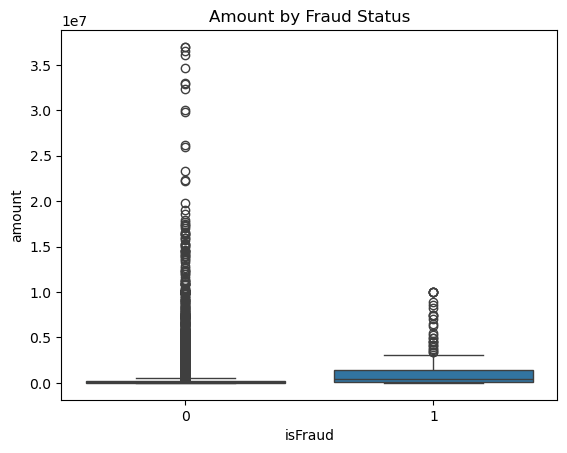

In [17]:
# Amount by fraud status
sns.boxplot(x="isFraud", y="amount", data=df)
plt.title("Amount by Fraud Status")
plt.show()

## Multivariate Analysis

lets many variables together 

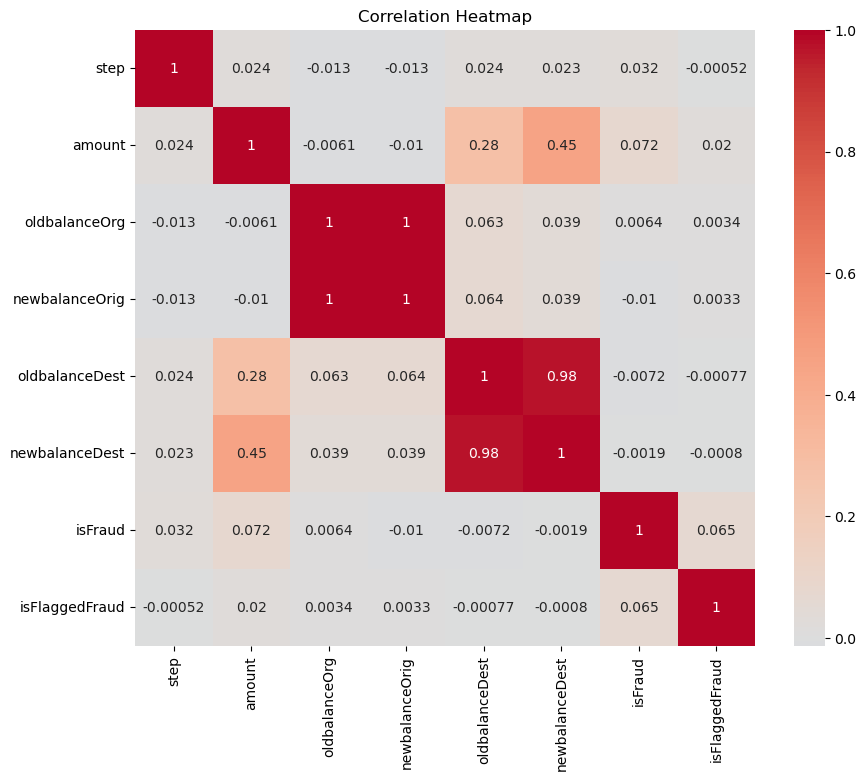

In [18]:
# correlation heatmap(only for numerical features)

numerical_features = df.select_dtypes(include=[np.number])
correlation_matrix = numerical_features.corr()  
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

After our EDA, it looks like only transfer and cash out contain fraud and hence we will perform futher analysis to uncover that 

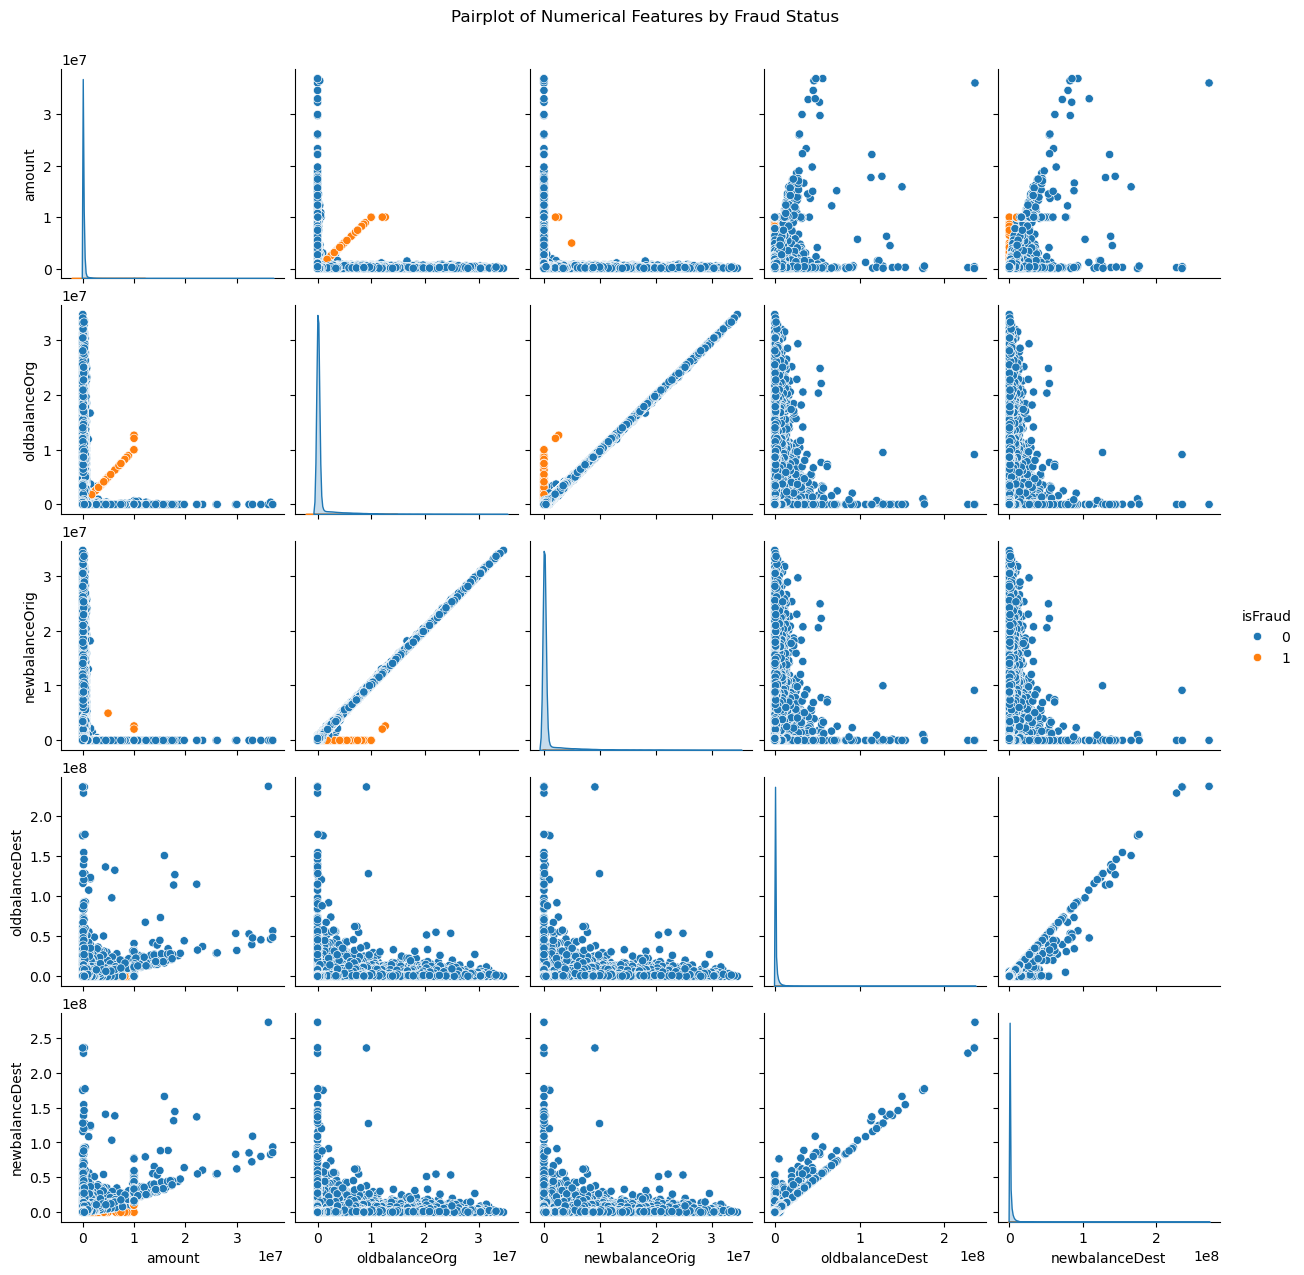

In [20]:
# Creating a pairplot to visualize the relationships between numerical features and fraud status

sns.pairplot(df, hue="isFraud", vars=["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest"])
plt.suptitle("Pairplot of Numerical Features by Fraud Status", y=1.02)
plt.show()  


## EDA Hypothesis

Based on the exploratory analysis, the strongest fraud signals appear to be:

- Transaction `type`: most fraud occurs in `TRANSFER` and `CASH_OUT` transactions.
- High transaction `amount` values, especially when paired with abnormal balance changes.
- Large drops in `newbalanceOrig` or unusual changes in `oldbalanceDest` / `newbalanceDest`.

These patterns suggest fraud is better predicted by transaction behavior and balance changes rather than account identifiers.